# Pembuatan Model Chatbot FAQ — TF-IDF + Cosine Similarity

Notebook ini membangun engine chatbot yang:
1. Memuat dan memproses seluruh dataset FAQ
2. Melatih TF-IDF Vectorizer
3. Mengevaluasi akurasi retrieval dengan berbagai threshold
4. Menyimpan model ke file `.pkl` siap pakai di Streamlit

---

## 1. Import & Load Data

In [1]:
import json, re, os, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'

with open('../data/faq.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

faqs = data['faq']
print(f'✅ Dataset dimuat: {len(faqs)} FAQ entries')

✅ Dataset dimuat: 15 FAQ entries


## 2. Preprocessing Teks Bahasa Indonesia

In [2]:
# Stopwords Bahasa Indonesia (custom, bisa diperluas)
STOPWORDS_ID = {
    'yang','dan','di','ke','dari','ini','itu','tidak','ada','dengan',
    'untuk','pada','atau','juga','sudah','saya','kami','kita','bisa',
    'akan','adalah','apakah','bagaimana','berapa','cara','gimana',
    'dong','ya','aja','sih','lah','nya','pun','punya','oleh','atas',
    'bawah','dalam','luar','antara','mau','ingin','tolong','mohon',
    'kalau','jika','bila','namun','tetapi','tapi','karena','sehingga',
    'agar','supaya','setelah','sebelum','ketika','saat','waktu','hari',
    'saya','kamu','anda','mereka','dia','itu','ini'
}

# Kamus sinonim untuk perbaikan query (opsional tapi meningkatkan akurasi)
SINONIM = {
    'gimana': 'bagaimana',
    'brp':    'berapa',
    'blm':    'belum',
    'sdh':    'sudah',
    'tdk':    'tidak',
    'gk':     'tidak',
    'ga':     'tidak',
    'nggak':  'tidak',
    'retur':  'kembalikan',
    'return': 'kembalikan',
    'refund': 'kembalikan',
    'bayar':  'pembayaran',
    'ongkir': 'pengiriman',
    'kirim':  'pengiriman',
    'ori':    'original',
    'asli':   'original',
    'pw':     'password',
    'pass':   'password',
    'daftar': 'registrasi',
    'reg':    'registrasi',
    'cs':     'customer service',
    'kontak': 'hubungi',
}

def preprocess(text: str) -> str:
    text = text.lower().strip()
    # Normalisasi sinonim
    words = text.split()
    words = [SINONIM.get(w, w) for w in words]
    text  = ' '.join(words)
    # Hapus karakter non-alfanumerik
    text  = re.sub(r'[^a-z0-9\s]', ' ', text)
    text  = re.sub(r'\s+', ' ', text).strip()
    # Hapus stopwords
    return ' '.join(w for w in text.split() if w not in STOPWORDS_ID and len(w) > 1)

# Test preprocessing
tests = [
    'Gimana cara bayar pakai gopay?',
    'Mau retur barang, gimana caranya?',
    'Lupa pw akun gk bisa login',
]
print('=== TEST PREPROCESSING ===')
for t in tests:
    print(f'  Input : {t}')
    print(f'  Output: {preprocess(t)}')
    print()

=== TEST PREPROCESSING ===
  Input : Gimana cara bayar pakai gopay?
  Output: pembayaran pakai gopay

  Input : Mau retur barang, gimana caranya?
  Output: kembalikan barang caranya

  Input : Lupa pw akun gk bisa login
  Output: lupa password akun login



## 3. Build Corpus & Train TF-IDF

In [3]:
# Bangun corpus: kumpulkan semua pertanyaan + variasi
corpus       = []  # teks untuk TF-IDF
corpus_raw   = []  # teks asli
corpus_idx   = []  # indeks ke FAQ mana

for i, faq in enumerate(faqs):
    # Pertanyaan utama
    corpus.append(preprocess(faq['pertanyaan']))
    corpus_raw.append(faq['pertanyaan'])
    corpus_idx.append(i)
    # Semua variasi
    for v in faq.get('variasi', []):
        corpus.append(preprocess(v))
        corpus_raw.append(v)
        corpus_idx.append(i)

print(f'Total corpus entries: {len(corpus)}')
print(f'  (pertanyaan utama + variasi dari {len(faqs)} FAQ)')

# Train TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # unigram + bigram
    min_df=1,
    max_df=0.95,
    sublinear_tf=True    # log normalization
)
tfidf_matrix = vectorizer.fit_transform(corpus)

print(f'\nTF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Jumlah fitur       : {len(vectorizer.get_feature_names_out())}')
print('\n✅ TF-IDF Vectorizer berhasil dilatih!')

Total corpus entries: 90
  (pertanyaan utama + variasi dari 15 FAQ)

TF-IDF matrix shape: (90, 291)
Jumlah fitur       : 291

✅ TF-IDF Vectorizer berhasil dilatih!


## 4. Fungsi Pencarian & Evaluasi Threshold

In [4]:
def get_answer(query: str, threshold: float = 0.15, top_k: int = 3) -> dict:
    """
    Cari jawaban paling relevan dari FAQ.
    
    Args:
        query     : pertanyaan pengguna
        threshold : skor minimum similarity agar dianggap match
        top_k     : jumlah kandidat teratas yang dikembalikan
    Returns:
        dict berisi jawaban, skor, kategori, dan kandidat lainnya
    """
    q_vec = vectorizer.transform([preprocess(query)])
    sims  = cosine_similarity(q_vec, tfidf_matrix).flatten()

    # Ambil top-k
    top_indices = sims.argsort()[::-1][:top_k]
    best_idx    = top_indices[0]
    best_score  = sims[best_idx]
    best_faq    = faqs[corpus_idx[best_idx]]

    if best_score < threshold:
        return {
            'found'    : False,
            'score'    : float(best_score),
            'answer'   : None,
            'question' : None,
            'kategori' : None,
            'candidates': []
        }

    # Kumpulkan kandidat lain (kategori berbeda)
    seen_faq = {corpus_idx[best_idx]}
    candidates = []
    for idx in top_indices[1:]:
        faq_i = corpus_idx[idx]
        if faq_i not in seen_faq and sims[idx] > threshold * 0.5:
            candidates.append({
                'question': faqs[faq_i]['pertanyaan'],
                'score'   : float(sims[idx]),
                'kategori': faqs[faq_i]['kategori']
            })
            seen_faq.add(faq_i)

    return {
        'found'    : True,
        'score'    : float(best_score),
        'answer'   : best_faq['jawaban'],
        'question' : best_faq['pertanyaan'],
        'kategori' : best_faq['kategori'],
        'candidates': candidates
    }

# --- Uji coba ---
test_queries = [
    'berapa lama pengiriman ke jawa',
    'mau kembalikan barang rusak',
    'cara bayar pakai transfer bank',
    'lupa password tidak bisa masuk',
    'barang ori ga sih',
    'pertanyaan random yang tidak ada di FAQ',  # edge case
]

print('=== UJI COBA FUNGSI GET_ANSWER ===')
for q in test_queries:
    result = get_answer(q, threshold=0.15)
    print(f'\n🔍 Query: "{q}"')
    if result['found']:
        print(f'   ✅ Match   : {result["question"]}')
        print(f'   Kategori  : {result["kategori"]}')
        print(f'   Score     : {result["score"]:.4f}')
    else:
        print(f'   ❌ Tidak ditemukan (score: {result["score"]:.4f})')

=== UJI COBA FUNGSI GET_ANSWER ===

🔍 Query: "berapa lama pengiriman ke jawa"
   ✅ Match   : Berapa lama waktu pengiriman pesanan saya?
   Kategori  : Pengiriman
   Score     : 0.7576

🔍 Query: "mau kembalikan barang rusak"
   ✅ Match   : Bagaimana cara mengembalikan barang?
   Kategori  : Pengembalian
   Score     : 0.7244

🔍 Query: "cara bayar pakai transfer bank"
   ✅ Match   : Metode pembayaran apa saja yang tersedia?
   Kategori  : Pembayaran
   Score     : 0.7555

🔍 Query: "lupa password tidak bisa masuk"
   ✅ Match   : Lupa password, bagaimana cara reset?
   Kategori  : Akun
   Score     : 0.6311

🔍 Query: "barang ori ga sih"
   ✅ Match   : Apakah produk yang dijual original?
   Kategori  : Produk
   Score     : 0.7162

🔍 Query: "pertanyaan random yang tidak ada di FAQ"
   ❌ Tidak ditemukan (score: 0.0000)


## 5. Evaluasi Threshold Optimal

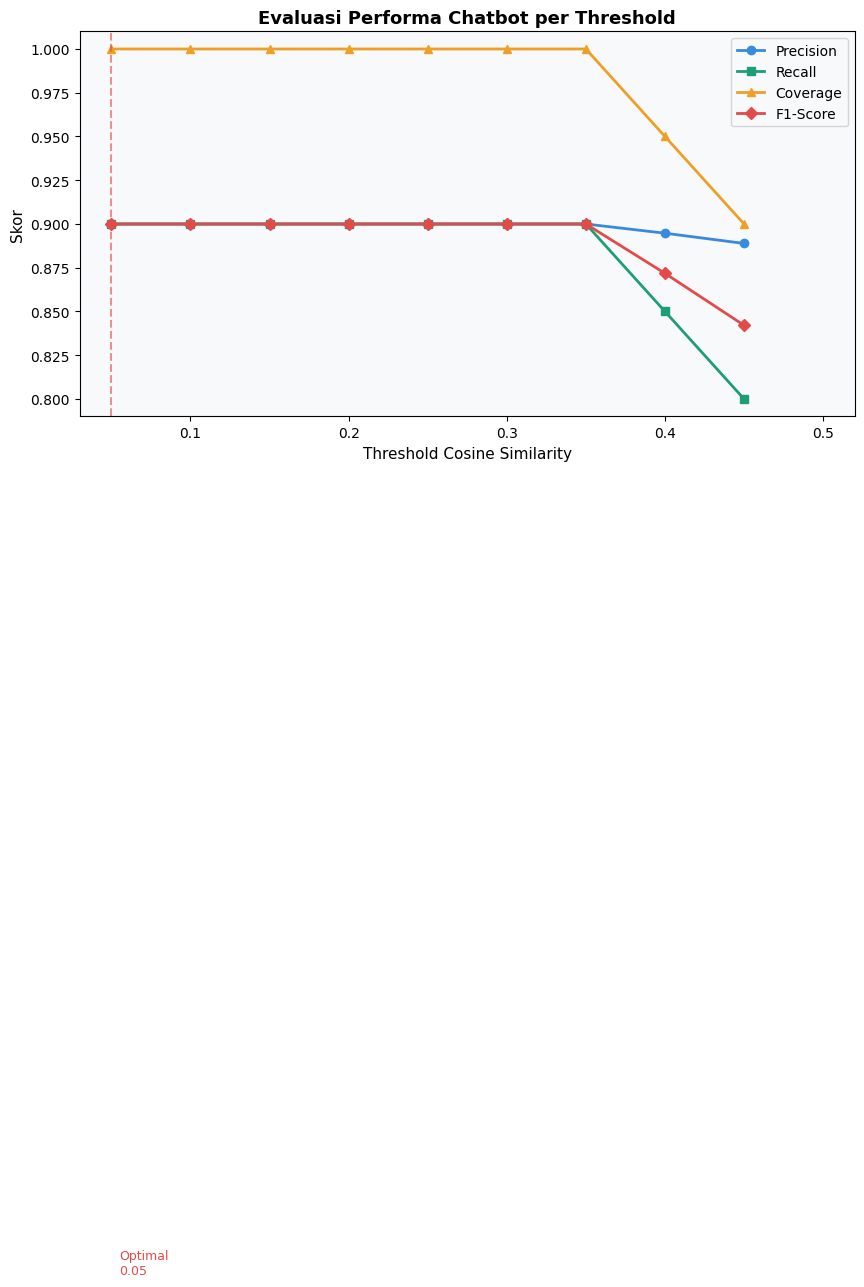


🏆 Threshold optimal: 0.05
   F1-Score         : 0.9000
   Precision        : 0.9000
   Recall           : 0.9000


In [5]:
# Dataset evaluasi manual (ground truth)
eval_data = [
    ('kapan pesanan saya sampai',              1),
    ('pengiriman ekspres ada tidak',           2),
    ('cara melacak resi',                      3),
    ('bisa bayar pakai apa',                   4),
    ('transaksi aman tidak',                   5),
    ('pembayaran gagal apa yang dilakukan',    6),
    ('prosedur retur barang',                  7),
    ('syarat pengembalian produk',             8),
    ('cara buat akun baru',                    9),
    ('lupa password gimana',                  10),
    ('barang asli atau palsu',                11),
    ('cara pesan produk',                     12),
    ('pakai voucher diskon bagaimana',        13),
    ('program poin reward ada',               14),
    ('nomor cs berapa',                       15),
    # Variasi bahasa
    ('ongkir berapa lama',                     1),
    ('same day delivery tersedia',             2),
    ('mau balik barang rusak',                 7),
    ('gk bisa login lupa pw',                 10),
    ('ori gak barangnya',                     11),
]

# Evaluasi dengan berbagai threshold
thresholds = np.arange(0.05, 0.50, 0.05)
results    = []

for thr in thresholds:
    correct = 0
    found   = 0
    for query, expected_id in eval_data:
        res = get_answer(query, threshold=thr)
        if res['found']:
            found += 1
            pred_id = corpus_idx[cosine_similarity(
                vectorizer.transform([preprocess(query)]), tfidf_matrix
            ).flatten().argmax()]
            if faqs[pred_id]['id'] == expected_id:
                correct += 1
    precision = correct / found if found > 0 else 0
    recall    = correct / len(eval_data)
    coverage  = found / len(eval_data)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    results.append({
        'threshold': thr, 'precision': precision,
        'recall': recall, 'coverage': coverage, 'f1': f1
    })

res_df = pd.DataFrame(results)

# Plot evaluasi
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_df['threshold'], res_df['precision'], 'o-', color='#378ADD', label='Precision', linewidth=2)
ax.plot(res_df['threshold'], res_df['recall'],    's-', color='#1D9E75', label='Recall',    linewidth=2)
ax.plot(res_df['threshold'], res_df['coverage'],  '^-', color='#EF9F27', label='Coverage',  linewidth=2)
ax.plot(res_df['threshold'], res_df['f1'],        'D-', color='#E24B4A', label='F1-Score',  linewidth=2)

# Tandai threshold optimal (F1 tertinggi)
best_thr = res_df.loc[res_df['f1'].idxmax(), 'threshold']
ax.axvline(best_thr, color='#E24B4A', linestyle='--', alpha=0.6)
ax.text(best_thr + 0.005, 0.3, f'Optimal\n{best_thr:.2f}', color='#E24B4A', fontsize=9)

ax.set_xlabel('Threshold Cosine Similarity', fontsize=11)
ax.set_ylabel('Skor', fontsize=11)
ax.set_title('Evaluasi Performa Chatbot per Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0.03, 0.52)
plt.tight_layout()
plt.savefig('plot_threshold_eval.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n🏆 Threshold optimal: {best_thr:.2f}')
print(f'   F1-Score         : {res_df.loc[res_df["f1"].idxmax(), "f1"]:.4f}')
print(f'   Precision        : {res_df.loc[res_df["f1"].idxmax(), "precision"]:.4f}')
print(f'   Recall           : {res_df.loc[res_df["f1"].idxmax(), "recall"]:.4f}')

BEST_THRESHOLD = best_thr

## 6. Simpan Model

In [6]:
os.makedirs('../model', exist_ok=True)

# Simpan semua komponen yang dibutuhkan chatbot
model_bundle = {
    'vectorizer'  : vectorizer,
    'tfidf_matrix': tfidf_matrix,
    'corpus'      : corpus,
    'corpus_raw'  : corpus_raw,
    'corpus_idx'  : corpus_idx,
    'faqs'        : faqs,
    'stopwords'   : STOPWORDS_ID,
    'sinonim'     : SINONIM,
    'threshold'   : float(BEST_THRESHOLD),
}

joblib.dump(model_bundle, '../model/chatbot_model.pkl')

# Simpan metadata
import json as _json
meta = {
    'total_faq'        : len(faqs),
    'total_corpus'     : len(corpus),
    'total_features'   : len(vectorizer.get_feature_names_out()),
    'threshold'        : float(BEST_THRESHOLD),
    'ngram_range'      : '(1,2)',
    'kategori'         : list(set(f['kategori'] for f in faqs)),
    'f1_score'         : float(res_df.loc[res_df['f1'].idxmax(), 'f1']),
}
with open('../model/metadata.json', 'w') as f:
    _json.dump(meta, f, indent=2, ensure_ascii=False)

print('✅ Model berhasil disimpan!')
print('   ../model/chatbot_model.pkl')
print('   ../model/metadata.json')
print()
print(_json.dumps(meta, indent=2, ensure_ascii=False))

✅ Model berhasil disimpan!
   ../model/chatbot_model.pkl
   ../model/metadata.json

{
  "total_faq": 15,
  "total_corpus": 90,
  "total_features": 291,
  "threshold": 0.05,
  "ngram_range": "(1,2)",
  "kategori": [
    "Promo",
    "Produk",
    "Pembayaran",
    "Pengembalian",
    "Akun",
    "Komplain",
    "Pengiriman"
  ],
  "f1_score": 0.8999999995
}
